# Phase 3: Exploratory Data Analysis & Visualization

## OB-GYN Provider Network Analysis

---

### Objective

Explore the cleaned datasets from Phase 2 to understand the structure, distribution, and early patterns in the OB-GYN referral network before formal network analysis in Phase 4. This notebook answers foundational questions:

- **Who** are the OB-GYN providers? (subspecialty mix, geographic spread)
- **Who** are the non-OB-GYN providers they share patients with? (classification breakdown)
- **How** are they connected? (referral volume, degree distribution, edge types)
- **Where** are the gaps? (provider density vs. maternal morbidity rates)

### Inputs (from Phase 2)

| File | Description |
|------|-------------|
| `obgyn_providers.csv` | All OB-GYN NPIs with practice location and sub-specialty |
| `other_providers.csv` | Non-OB-GYN NPIs with NUCC type, classification, specialization, and entity type |
| `obgyn_edges.csv` | All CMS shared patient pairs (including organizations) |
| `obgyn_edges_individuals.csv` | Individual-to-individual edges only (used for network analysis) |
| `county_morbidity_rates.csv` | County-level maternal morbidity rates |

### Sections

1. Setup & Load Data
2. OB-GYN Provider Distribution — subspecialty and geographic breakdown
3. Non-OB-GYN Provider Classification — entity types and individual specialist breakdown
4. Edge Weight Analysis — shared patient volume distributions
5. Network Degree Analysis — how connected is each provider?
6. Morbidity Rate Exploration — geographic variation in maternal outcomes
7. Provider Density vs. Morbidity — early correlation signals
8. Key Findings Summary

---

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from datetime import datetime
from collections import Counter

# Plot styling
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

# Consistent color palette for the project
PROJECT_COLORS = {
    "primary": "#2c7fb8",
    "secondary": "#7fcdbb",
    "accent": "#d95f0e",
    "obgyn_obgyn": "#2c7fb8",
    "obgyn_other": "#7fcdbb",
    "highlight": "#d95f0e"
}

print(f"Notebook executed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Notebook executed: 2026-02-22 18:30:13


In [2]:
# -------------------------------------------------------------------
# FILE PATHS
# -------------------------------------------------------------------

OUTPUT_DIR = Path("../data/outputs")

providers = pd.read_csv(OUTPUT_DIR / "obgyn_providers.csv", dtype=str)
other_providers = pd.read_csv(OUTPUT_DIR / "other_providers.csv", dtype=str)
edges_all = pd.read_csv(OUTPUT_DIR / "obgyn_edges.csv", dtype={"npi1": str, "npi2": str}, low_memory=False)
edges = pd.read_csv(OUTPUT_DIR / "obgyn_edges_individuals.csv", dtype={"npi1": str, "npi2": str}, low_memory=False)
morbidity = pd.read_csv(OUTPUT_DIR / "county_morbidity_rates.csv", dtype={"fips": str})

print(f"OB-GYN Providers:       {len(providers):,} rows x {len(providers.columns)} cols")
print(f"Non-OB-GYN Providers:   {len(other_providers):,} rows x {len(other_providers.columns)} cols")
print(f"Edges (all):            {len(edges_all):,} rows x {len(edges_all.columns)} cols")
print(f"Edges (individuals):    {len(edges):,} rows x {len(edges.columns)} cols")
print(f"Morbidity:              {len(morbidity):,} rows x {len(morbidity.columns)} cols")

# Entity type breakdown
print(f"\nNon-OB-GYN entity types:")
print(other_providers["entity_type"].value_counts().to_string())

OB-GYN Providers:       60,422 rows x 9 cols
Non-OB-GYN Providers:   46,527 rows x 13 cols
Edges (all):            243,052 rows x 28 cols
Edges (individuals):    105,891 rows x 28 cols
Morbidity:              626 rows x 6 cols

Non-OB-GYN entity types:
entity_type
Individual      37114
Organization     8031
Unknown          1382


In [3]:
# -------------------------------------------------------------------
# QUICK LOOK: Confirm data loaded correctly
# -------------------------------------------------------------------

print("=== OB-GYN Providers ===")
display(providers.head(3))
print("\n=== Non-OB-GYN Providers ===")
display(other_providers.head(3))
print("\n=== Edges ===")
display(edges.head(3))
print("\n=== Morbidity ===")
display(morbidity.head(3))

=== OB-GYN Providers ===


,npi,last_name,first_name,taxonomy_code,subspecialty,city,state,zip_raw,zip5
0,1487657532,HUEBERT,ALLISON,207V00000X,Obstetrics & Gynecology,TULSA,OK,741352527,74135
1,1396748349,GRUNERT,GEORGE,207VE0102X,Reproductive Endocrinology,HOUSTON,TX,770632313,77063
2,1861495814,SMITH,FRANCISCO,207VX0201X,Gynecologic Oncology,NAPLES,FL,341101497,34110



=== Non-OB-GYN Providers ===


,npi,entity_type_code,last_name,first_name,taxonomy_code,provider_type,classification,specialization,city,state,zip_raw,entity_type,zip5
0,1306849450,NaN,NaN,NaN,NaN,Unknown,Unknown,NaN,NaN,NaN,NaN,Unknown,NaN
1,1114920261,1,THACKER,RICHARD,207R00000X,Allopathic & Osteopathic Physicians,Internal Medicine,NaN,TALLAHASSEE,FL,323088417,Individual,32308
2,1073516027,1,CHANG,JOHN,207W00000X,Allopathic & Osteopathic Physicians,Ophthalmology,NaN,PEARL RIVER,NY,109652029,Individual,10965



=== Edges ===


,npi1,npi2,paircount,benecount,samedaycount,year,days,begdate,enddate,edge_type,...,npi1_zip5,npi2_subspecialty,npi2_other_type,npi2_other_classification,npi2_other_specialization,npi2_specialty,npi2_entity,npi2_city,npi2_state,npi2_zip5
0,1003000480,1548451727,30,14,1,2015,60,1/1/2015,10/1/2015,obgyn_other,...,80045,Obstetrics & Gynecology,NaN,NaN,NaN,Obstetrics & Gynecology,Individual,DENVER,CO,80222
1,1003001363,1205912847,111,17,1,2015,60,1/1/2015,10/1/2015,obgyn_other,...,92243,Female Pelvic Medicine and Reconstructive Surgery,NaN,NaN,NaN,Female Pelvic Medicine and Reconstructive Surgery,Individual,EL CENTRO,CA,92243
2,1003002627,1043246499,137,14,1,2015,60,1/1/2015,10/1/2015,obgyn_other,...,77566,NaN,Allopathic & Osteopathic Physicians,Anesthesiology,NaN,Anesthesiology,Individual,ANGLETON,TX,77515



=== Morbidity ===


,county_name,fips,total_births,morbidity_births,morbidity_rate,state
0,"Baldwin County, AL",01003,2247,43.0,0.019137,AL
1,"Calhoun County, AL",01015,1357,16.0,0.011791,AL
2,"Etowah County, AL",01055,1214,11.0,0.009061,AL


---

## 2. OB-GYN Provider Distribution

Understanding the composition and geographic spread of OB-GYN providers in our dataset.

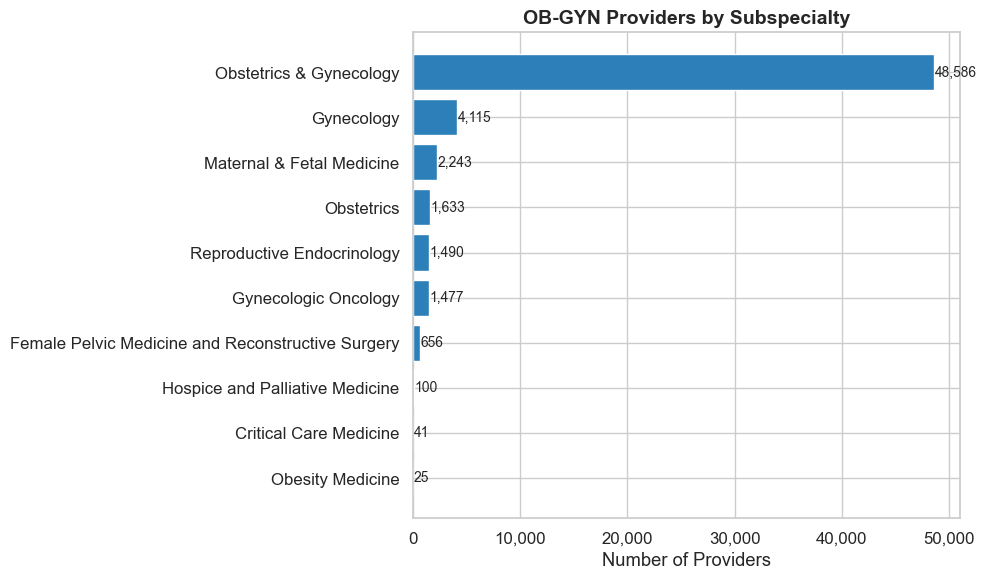


Subspecialty counts:
  Obstetrics & Gynecology                                 48,586 (80.4%)
  Gynecology                                               4,115 (6.8%)
  Maternal & Fetal Medicine                                2,243 (3.7%)
  Obstetrics                                               1,633 (2.7%)
  Reproductive Endocrinology                               1,490 (2.5%)
  Gynecologic Oncology                                     1,477 (2.4%)
  Female Pelvic Medicine and Reconstructive Surgery          656 (1.1%)
  Hospice and Palliative Medicine                            100 (0.2%)
  Critical Care Medicine                                      41 (0.1%)
  Obesity Medicine                                            25 (0.0%)


In [4]:
# -------------------------------------------------------------------
# 2a. Subspecialty Distribution
# -------------------------------------------------------------------

subspec_counts = providers["subspecialty"].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    subspec_counts.index[::-1],
    subspec_counts.values[::-1],
    color=PROJECT_COLORS["primary"],
    edgecolor="white"
)

# Add count labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 50, bar.get_y() + bar.get_height()/2,
            f"{int(width):,}", va="center", fontsize=10)

ax.set_xlabel("Number of Providers")
ax.set_title("OB-GYN Providers by Subspecialty", fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print("\nSubspecialty counts:")
for spec, count in subspec_counts.items():
    print(f"  {spec:<55} {count:>6,} ({count/len(providers)*100:.1f}%)")

In [5]:
# -------------------------------------------------------------------
# EXPORT: Subspecialty distribution for Tableau
# -------------------------------------------------------------------

subspec_export = providers["subspecialty"].value_counts().reset_index()
subspec_export.columns = ["Subspecialty", "Provider Count"]
subspec_export["Percent of Total"] = (subspec_export["Provider Count"] / len(providers) * 100).round(1)

subspec_export.to_csv(OUTPUT_DIR / "tableau_subspecialty_distribution.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'tableau_subspecialty_distribution.csv'}")
display(subspec_export)

Saved: ../data/outputs/tableau_subspecialty_distribution.csv


,Subspecialty,Provider Count,Percent of Total
0,Obstetrics & Gynecology,48586,80.4
1,Gynecology,4115,6.8
2,Maternal & Fetal Medicine,2243,3.7
3,Obstetrics,1633,2.7
4,Reproductive Endocrinology,1490,2.5
5,Gynecologic Oncology,1477,2.4
6,Female Pelvic Medicine and Reconstructive Surgery,656,1.1
7,Hospice and Palliative Medicine,100,0.2
8,Critical Care Medicine,41,0.1
9,Obesity Medicine,25,0.0


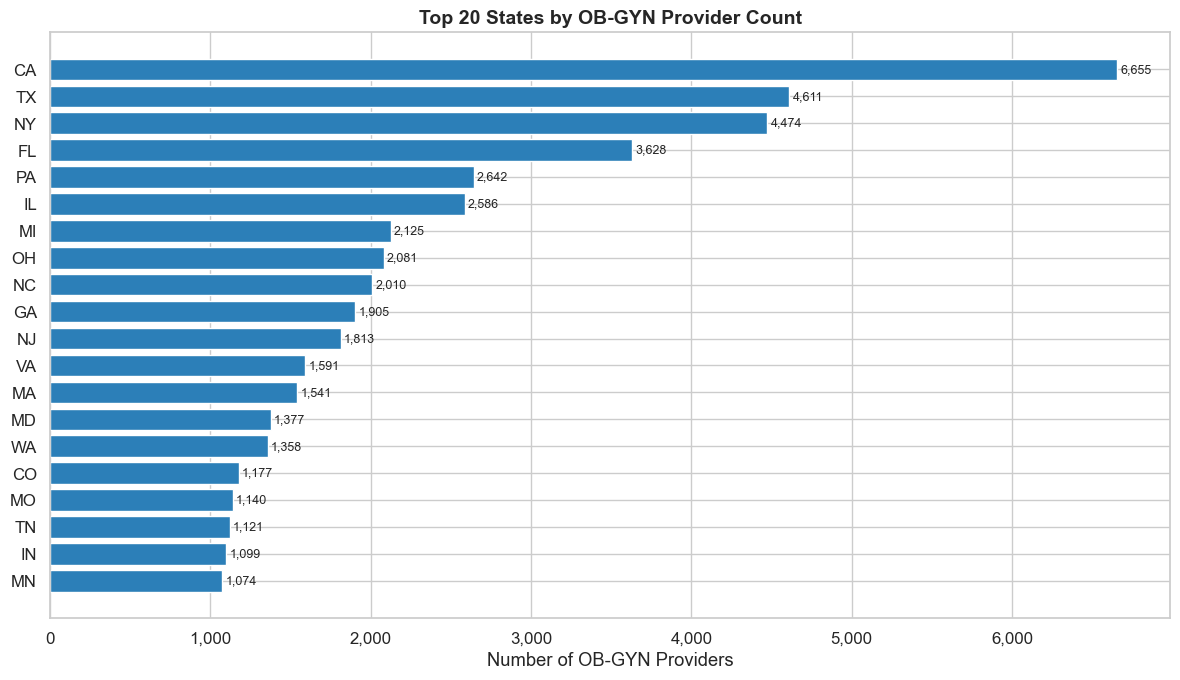


Total states/territories represented: 97
Top 5 states account for 22,010 providers (36.4% of total)


In [6]:
# -------------------------------------------------------------------
# 2b. Geographic Distribution — Top 20 States
# -------------------------------------------------------------------

state_counts = providers["state"].value_counts()

fig, ax = plt.subplots(figsize=(12, 7))
top20 = state_counts.head(20)
ax.barh(
    top20.index[::-1],
    top20.values[::-1],
    color=PROJECT_COLORS["primary"],
    edgecolor="white"
)

for i, (val, name) in enumerate(zip(top20.values[::-1], top20.index[::-1])):
    ax.text(val + 20, i, f"{val:,}", va="center", fontsize=9)

ax.set_xlabel("Number of OB-GYN Providers")
ax.set_title("Top 20 States by OB-GYN Provider Count", fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print(f"\nTotal states/territories represented: {providers['state'].nunique()}")
print(f"Top 5 states account for {state_counts.head(5).sum():,} providers "
      f"({state_counts.head(5).sum()/len(providers)*100:.1f}% of total)")

In [7]:
# -------------------------------------------------------------------
# EXPORT: State-level OB-GYN counts for Tableau choropleth map
# -------------------------------------------------------------------

# All 50 states + DC
ALL_STATES = [
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "DC", "FL",
    "GA", "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME",
    "MD", "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH",
    "NJ", "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI",
    "SC", "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY"
]

state_counts = providers["state"].value_counts().reset_index()
state_counts.columns = ["State", "OB-GYN Count"]

# Create full 51-row frame with zeros for missing states
all_states_df = pd.DataFrame({"State": ALL_STATES})
state_export = all_states_df.merge(state_counts, on="State", how="left")
state_export["OB-GYN Count"] = state_export["OB-GYN Count"].fillna(0).astype(int)
state_export = state_export.sort_values("State").reset_index(drop=True)

state_export.to_csv(OUTPUT_DIR / "tableau_obgyn_by_state.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'tableau_obgyn_by_state.csv'}")
print(f"States with providers: {(state_export['OB-GYN Count'] > 0).sum()}")
print(f"States with zero:      {(state_export['OB-GYN Count'] == 0).sum()}")
display(state_export)

Saved: ../data/outputs/tableau_obgyn_by_state.csv
States with providers: 51
States with zero:      0


,State,OB-GYN Count
0,AK,141
1,AL,706
2,AR,365
3,AZ,1073
4,CA,6655
5,CO,1177
6,CT,956
7,DC,338
8,DE,190
9,FL,3628


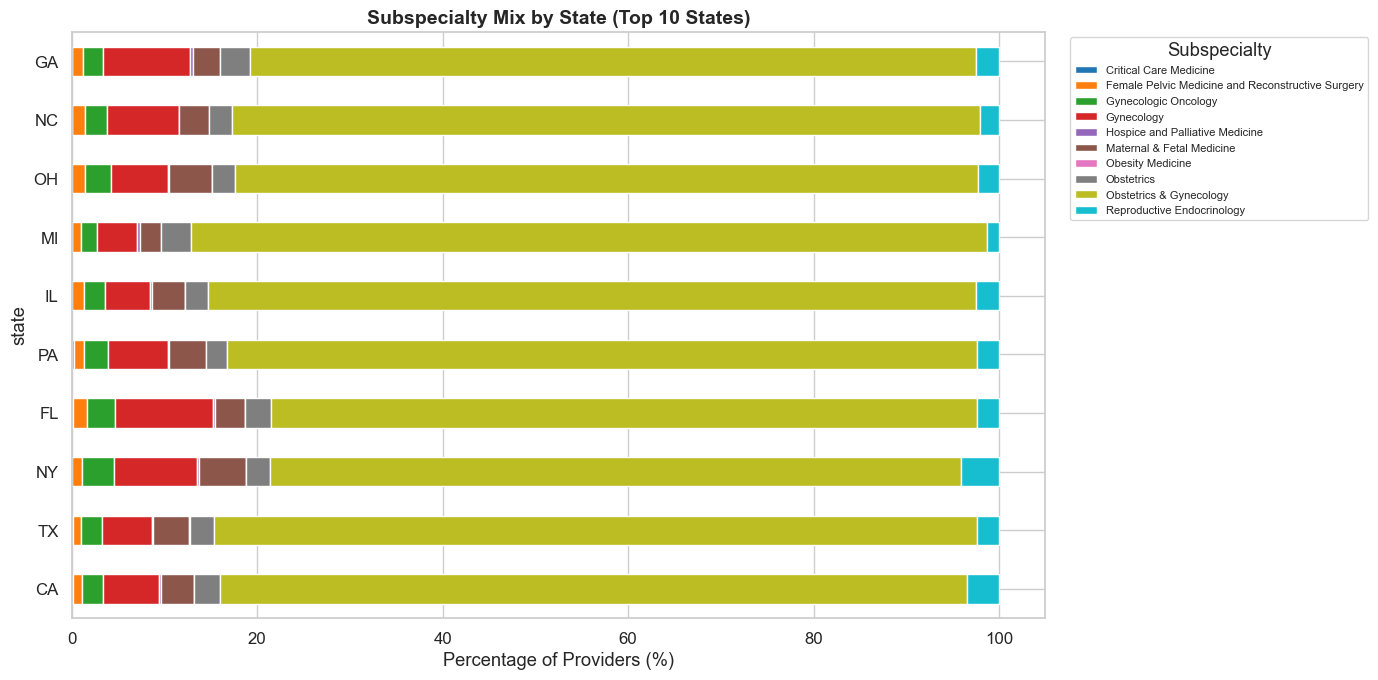

In [8]:
# -------------------------------------------------------------------
# 2c. Subspecialty Mix by Top 10 States
# -------------------------------------------------------------------

top10_states = state_counts["State"].head(10).tolist()
top_state_data = providers[providers["state"].isin(top10_states)]

# Cross-tabulate
cross = pd.crosstab(
    top_state_data["state"],
    top_state_data["subspecialty"],
    normalize="index"  # row percentages
) * 100

# Reorder rows by total provider count
cross = cross.loc[top10_states]

fig, ax = plt.subplots(figsize=(14, 7))
cross.plot(kind="barh", stacked=True, ax=ax, colormap="tab10", edgecolor="white")
ax.set_xlabel("Percentage of Providers (%)")
ax.set_title("Subspecialty Mix by State (Top 10 States)", fontsize=14, fontweight="bold")
ax.legend(title="Subspecialty", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
# -------------------------------------------------------------------
# EXPORT: Subspecialty by State for Tableau treemap and heatmap
# -------------------------------------------------------------------

# Only keep legitimate 50 states + DC
US_STATES = {
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "DC", "FL",
    "GA", "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME",
    "MD", "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH",
    "NJ", "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI",
    "SC", "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY"
}

providers_us = providers[providers["state"].isin(US_STATES)]
print(f"Filtered to US states: {len(providers_us):,} of {len(providers):,} providers "
      f"({len(providers) - len(providers_us):,} excluded)")

# Full cross-tabulation (counts, not percentages) — all states
state_subspec = providers_us.groupby(["state", "subspecialty"]).size().reset_index(name="Provider Count")

# Add percentage within each state
state_totals = providers_us.groupby("state").size().reset_index(name="State Total")
state_subspec = state_subspec.merge(state_totals, on="state")
state_subspec["Percent of State"] = (state_subspec["Provider Count"] / state_subspec["State Total"] * 100).round(1)

state_subspec.columns = ["State", "Subspecialty", "Provider Count", "State Total", "Percent of State"]

# --- Treemap format ---
state_subspec.to_csv(OUTPUT_DIR / "tableau_treemap_state_subspecialty.csv", index=False)
print(f"Saved treemap file: {len(state_subspec):,} rows (state × subspecialty combinations)")
display(state_subspec.head(10))

# --- Heatmap format ---
heatmap = state_subspec.pivot(index="State", columns="Subspecialty", values="Percent of State").fillna(0)
heatmap = heatmap.reset_index()
heatmap.to_csv(OUTPUT_DIR / "tableau_heatmap_state_subspecialty.csv", index=False)
print(f"\nSaved heatmap file: {len(heatmap)} states × {len(heatmap.columns)-1} subspecialties")
display(heatmap.head(10))

Filtered to US states: 59,790 of 60,422 providers (632 excluded)
Saved treemap file: 411 rows (state × subspecialty combinations)


,State,Subspecialty,Provider Count,State Total,Percent of State
0,AK,Female Pelvic Medicine and Reconstructive Surgery,1,141,0.7
1,AK,Gynecologic Oncology,2,141,1.4
2,AK,Gynecology,10,141,7.1
3,AK,Maternal & Fetal Medicine,3,141,2.1
4,AK,Obesity Medicine,1,141,0.7
5,AK,Obstetrics,5,141,3.5
6,AK,Obstetrics & Gynecology,119,141,84.4
7,AL,Female Pelvic Medicine and Reconstructive Surgery,8,706,1.1
8,AL,Gynecologic Oncology,24,706,3.4
9,AL,Gynecology,63,706,8.9



Saved heatmap file: 51 states × 10 subspecialties


Subspecialty,State,Critical Care Medicine,Female Pelvic Medicine and Reconstructive Surgery,Gynecologic Oncology,Gynecology,Hospice and Palliative Medicine,Maternal & Fetal Medicine,Obesity Medicine,Obstetrics,Obstetrics & Gynecology,Reproductive Endocrinology
0,AK,0.0,0.7,1.4,7.1,0.0,2.1,0.7,3.5,84.4,0.0
1,AL,0.0,1.1,3.4,8.9,0.1,4.5,0.0,2.3,76.6,2.8
2,AR,0.3,0.8,1.4,11.0,0.0,2.5,0.0,4.1,79.5,0.5
3,AZ,0.2,1.8,2.4,8.5,0.1,4.8,0.0,2.6,78.3,1.4
4,CA,0.1,1.0,2.2,6.0,0.3,3.5,0.0,2.8,80.4,3.4
5,CO,0.1,0.8,1.9,6.1,0.1,4.1,0.0,1.7,82.9,2.2
6,CT,0.0,1.8,2.1,8.4,0.1,4.2,0.1,1.3,77.5,4.5
7,DC,0.0,2.1,2.7,8.9,0.0,5.0,0.0,1.8,76.9,2.4
8,DE,0.5,1.1,3.7,3.2,0.0,4.2,0.0,1.1,83.2,2.6
9,FL,0.1,1.5,3.0,10.6,0.2,3.2,0.1,2.8,76.1,2.3


---

## 3. Non-OB-GYN Provider Classification

These are the other types of providers that share Medicare patients with OB-GYNs. The non-OB-GYN side includes both **individual providers** (doctors, NPs, PAs) and **organizations** (hospitals, labs, facilities). We first show the entity type split, then focus on **individuals only** for the classification breakdown — since our network analysis excludes organizations.

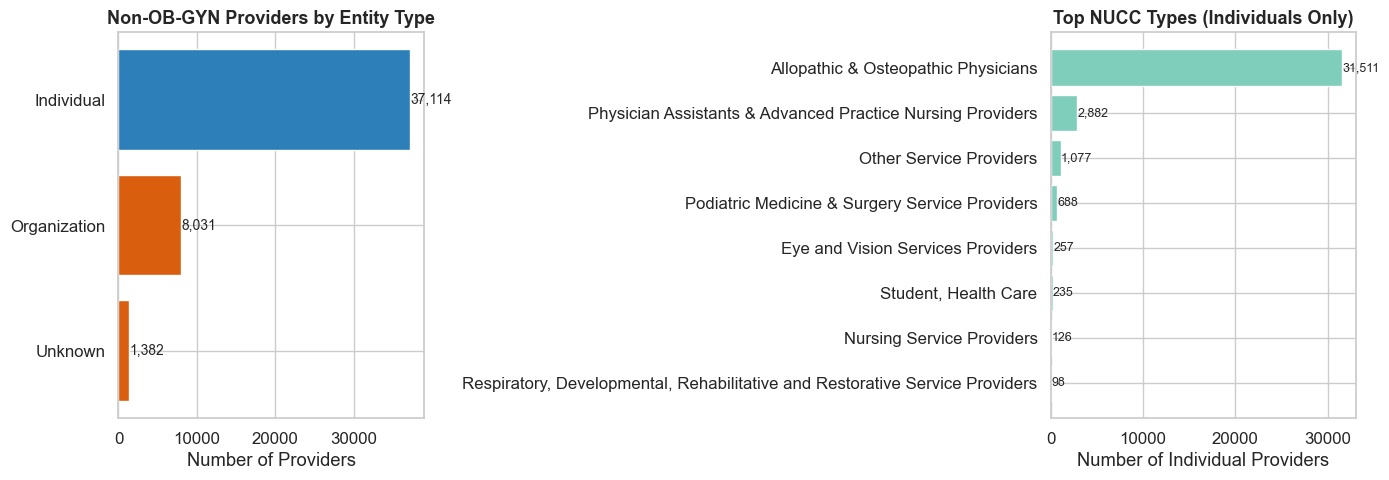

Entity type summary:
  Individuals:    37,114 (79.8%)
  Organizations:  8,031 (17.3%)

Individual provider types (23 distinct):
  Allopathic & Osteopathic Physicians                          31,511 (84.9%)
  Physician Assistants & Advanced Practice Nursing Providers    2,882 (7.8%)
  Other Service Providers                                       1,077 (2.9%)
  Podiatric Medicine & Surgery Service Providers                  688 (1.9%)
  Eye and Vision Services Providers                               257 (0.7%)
  Student, Health Care                                            235 (0.6%)
  Nursing Service Providers                                       126 (0.3%)
  Respiratory, Developmental, Rehabilitative and Restorative Service Providers     98 (0.3%)
  Behavioral Health & Social Service Providers                     75 (0.2%)
  Chiropractic Providers                                           47 (0.1%)
  Unknown                                                          37 (0.1%)
  Techno

In [10]:
# -------------------------------------------------------------------
# 3a. Non-OB-GYN Entity Type Breakdown
# -------------------------------------------------------------------

entity_counts = other_providers["entity_type"].value_counts()

# Filter to individuals only for provider type analysis
indiv_providers = other_providers[other_providers["entity_type"] == "Individual"]
org_providers = other_providers[other_providers["entity_type"] == "Organization"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Entity type bar chart
ax = axes[0]
colors_entity = [PROJECT_COLORS["primary"] if e == "Individual" else PROJECT_COLORS["accent"]
                 for e in entity_counts.index]
bars = ax.barh(entity_counts.index[::-1], entity_counts.values[::-1],
               color=colors_entity[::-1], edgecolor="white")
for bar in bars:
    width = bar.get_width()
    ax.text(width + 50, bar.get_y() + bar.get_height()/2,
            f"{int(width):,}", va="center", fontsize=10)
ax.set_xlabel("Number of Providers")
ax.set_title("Non-OB-GYN Providers by Entity Type", fontsize=13, fontweight="bold")

# Right: Top NUCC Types (individuals only)
type_counts_indiv = indiv_providers["provider_type"].value_counts()
ax = axes[1]
top_types = type_counts_indiv.head(8)
bars = ax.barh(top_types.index[::-1], top_types.values[::-1],
               color=PROJECT_COLORS["secondary"], edgecolor="white")
for bar in bars:
    width = bar.get_width()
    ax.text(width + 30, bar.get_y() + bar.get_height()/2,
            f"{int(width):,}", va="center", fontsize=9)
ax.set_xlabel("Number of Individual Providers")
ax.set_title("Top NUCC Types (Individuals Only)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Entity type summary:")
print(f"  Individuals:    {len(indiv_providers):,} ({len(indiv_providers)/len(other_providers)*100:.1f}%)")
print(f"  Organizations:  {len(org_providers):,} ({len(org_providers)/len(other_providers)*100:.1f}%)")

print(f"\nIndividual provider types ({len(type_counts_indiv)} distinct):")
for ptype, count in type_counts_indiv.items():
    print(f"  {ptype:<60} {count:>6,} ({count/len(indiv_providers)*100:.1f}%)")

In [11]:
# -------------------------------------------------------------------
# EXPORT: Non-OB-GYN Entity Type data for Tableau
# -------------------------------------------------------------------

# --- 1. Entity Type Breakdown (for horizontal bar chart in Tableau) ---
entity_export = other_providers["entity_type"].value_counts().reset_index()
entity_export.columns = ["Entity Type", "Provider Count"]
entity_export["Percent of Total"] = (
    entity_export["Provider Count"] / len(other_providers) * 100
).round(1)

entity_export.to_csv(OUTPUT_DIR / "tableau_entity_type_breakdown.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'tableau_entity_type_breakdown.csv'}")
display(entity_export)

# --- 2. Individual Provider Types (for table in Tableau) ---
indiv_providers_local = other_providers[other_providers["entity_type"] == "Individual"]

type_export = indiv_providers_local["provider_type"].value_counts().reset_index()
type_export.columns = ["Provider Type", "Provider Count"]
type_export["Percent of Individuals"] = (
    type_export["Provider Count"] / len(indiv_providers_local) * 100
).round(1)

type_export.to_csv(OUTPUT_DIR / "tableau_individual_provider_types.csv", index=False)
print(f"\nSaved: {OUTPUT_DIR / 'tableau_individual_provider_types.csv'}")
display(type_export)

Saved: ../data/outputs/tableau_entity_type_breakdown.csv


,Entity Type,Provider Count,Percent of Total
0,Individual,37114,79.8
1,Organization,8031,17.3
2,Unknown,1382,3.0



Saved: ../data/outputs/tableau_individual_provider_types.csv


,Provider Type,Provider Count,Percent of Individuals
0,Allopathic & Osteopathic Physicians,31511,84.9
1,Physician Assistants & Advanced Practice Nursi...,2882,7.8
2,Other Service Providers,1077,2.9
3,Podiatric Medicine & Surgery Service Providers,688,1.9
4,Eye and Vision Services Providers,257,0.7
5,"Student, Health Care",235,0.6
6,Nursing Service Providers,126,0.3
7,"Respiratory, Developmental, Rehabilitative and...",98,0.3
8,Behavioral Health & Social Service Providers,75,0.2
9,Chiropractic Providers,47,0.1


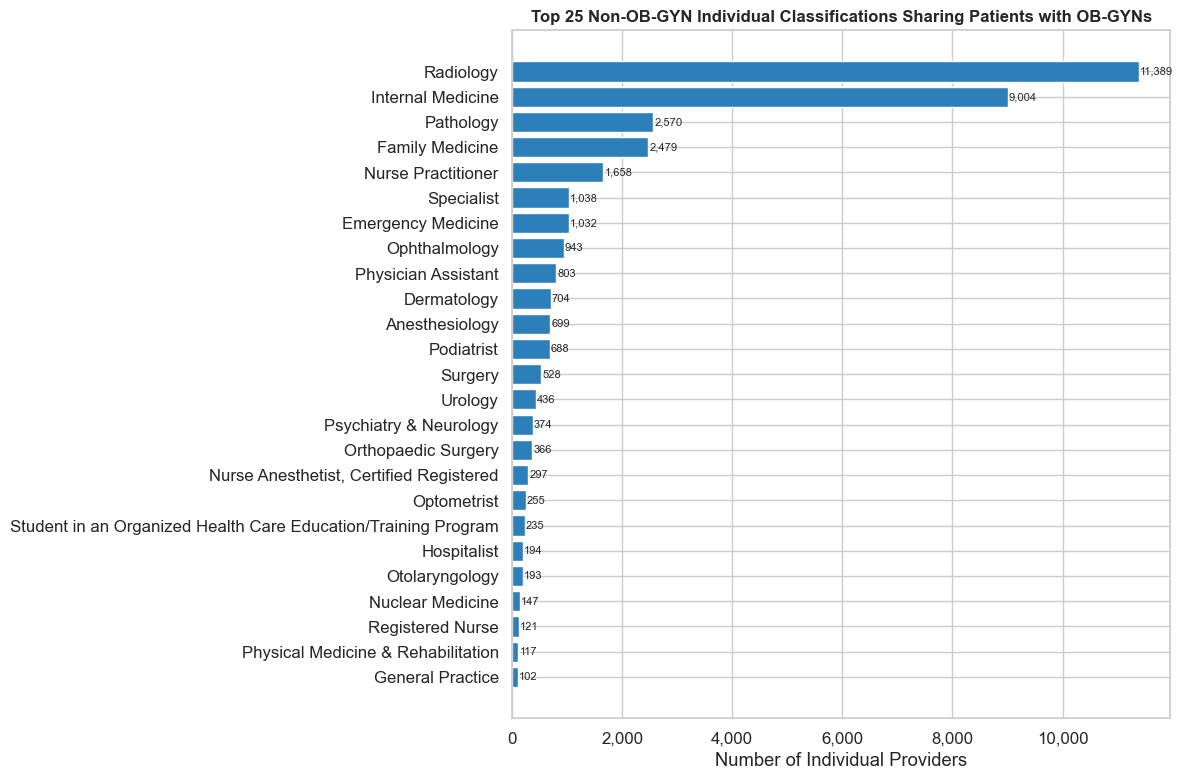


Total distinct individual classifications: 81
Top 10 account for 31,620 providers (85.2% of non-OB-GYN individuals)


In [12]:
# -------------------------------------------------------------------
# 3b. Top 25 Non-OB-GYN Classifications (Individuals Only)
# -------------------------------------------------------------------

indiv_class_counts = indiv_providers["classification"].value_counts()

fig, ax = plt.subplots(figsize=(12, 8))
top25 = indiv_class_counts.head(25)
bars = ax.barh(top25.index[::-1], top25.values[::-1],
               color=PROJECT_COLORS["primary"], edgecolor="white")

for bar in bars:
    width = bar.get_width()
    ax.text(width + 20, bar.get_y() + bar.get_height()/2,
            f"{int(width):,}", va="center", fontsize=8)

ax.set_xlabel("Number of Individual Providers")
ax.set_title("Top 25 Non-OB-GYN Individual Classifications Sharing Patients with OB-GYNs",
             fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print(f"\nTotal distinct individual classifications: {len(indiv_class_counts)}")
print(f"Top 10 account for {indiv_class_counts.head(10).sum():,} providers "
      f"({indiv_class_counts.head(10).sum()/len(indiv_providers)*100:.1f}% of non-OB-GYN individuals)")

In [13]:
# -------------------------------------------------------------------
# EXPORT: All Non-OB-GYN Individual Classifications for Tableau
# -------------------------------------------------------------------
# Format: packed bubble chart — each bubble = 1 classification
#   Dimension: Classification (label)
#   Measure:   Provider Count (bubble size)
#   Color by:  Provider Type (NUCC parent category)
# -------------------------------------------------------------------

indiv_class_export = (
    indiv_providers
    .groupby(["provider_type", "classification"])
    .size()
    .reset_index(name="Provider Count")
)
indiv_class_export.columns = ["Provider Type", "Classification", "Provider Count"]
indiv_class_export["Percent of Individuals"] = (
    indiv_class_export["Provider Count"] / len(indiv_providers) * 100
).round(2)
indiv_class_export = indiv_class_export.sort_values("Provider Count", ascending=False).reset_index(drop=True)

indiv_class_export.to_csv(OUTPUT_DIR / "tableau_nonobgyn_classifications_bubble.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'tableau_nonobgyn_classifications_bubble.csv'}")
print(f"  {len(indiv_class_export)} classifications")
print(f"  {indiv_class_export['Provider Type'].nunique()} parent provider types (for color)")
display(indiv_class_export)

Saved: ../data/outputs/tableau_nonobgyn_classifications_bubble.csv
  81 classifications
  23 parent provider types (for color)


,Provider Type,Classification,Provider Count,Percent of Individuals
0,Allopathic & Osteopathic Physicians,Radiology,11389,30.69
1,Allopathic & Osteopathic Physicians,Internal Medicine,9004,24.26
2,Allopathic & Osteopathic Physicians,Pathology,2570,6.92
3,Allopathic & Osteopathic Physicians,Family Medicine,2479,6.68
4,Physician Assistants & Advanced Practice Nursi...,Nurse Practitioner,1658,4.47
...,...,...,...,...
76,Other Service Providers,"Sleep Specialist, PhD",1,0.00
77,Other Service Providers,Military Health Care Provider,1,0.00
78,Other Service Providers,Contractor,1,0.00
79,Other Service Providers,Case Manager/Care Coordinator,1,0.00


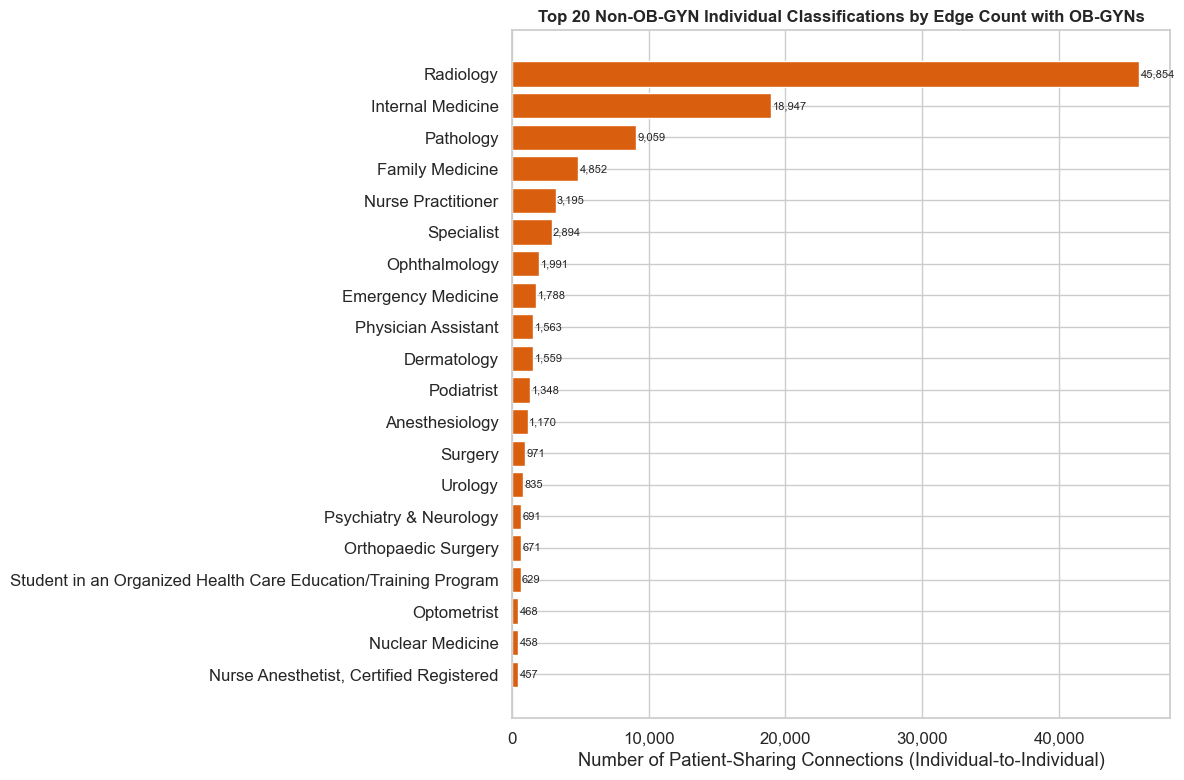


Top 10 non-OB-GYN individual classifications by connection volume:
  Radiology                                            45,854 edges
  Internal Medicine                                    18,947 edges
  Pathology                                             9,059 edges
  Family Medicine                                       4,852 edges
  Nurse Practitioner                                    3,195 edges
  Specialist                                            2,894 edges
  Ophthalmology                                         1,991 edges
  Emergency Medicine                                    1,788 edges
  Physician Assistant                                   1,563 edges
  Dermatology                                           1,559 edges


In [14]:
# -------------------------------------------------------------------
# 3c. Edge counts by non-OB-GYN classification (individual-to-individual)
# -------------------------------------------------------------------
# Uses the individuals-only edge list so facilities are excluded.
# -------------------------------------------------------------------

obgyn_other_edges = edges[edges["edge_type"] == "obgyn_other"].copy()

# The non-OB-GYN side could be npi1 or npi2 — collect both
other_class_edges = pd.concat([
    obgyn_other_edges["npi1_other_classification"].dropna(),
    obgyn_other_edges["npi2_other_classification"].dropna()
])

edge_by_class = other_class_edges.value_counts()

fig, ax = plt.subplots(figsize=(12, 8))
top20 = edge_by_class.head(20)
bars = ax.barh(top20.index[::-1], top20.values[::-1],
               color=PROJECT_COLORS["accent"], edgecolor="white")

for bar in bars:
    width = bar.get_width()
    ax.text(width + 100, bar.get_y() + bar.get_height()/2,
            f"{int(width):,}", va="center", fontsize=8)

ax.set_xlabel("Number of Patient-Sharing Connections (Individual-to-Individual)")
ax.set_title("Top 20 Non-OB-GYN Individual Classifications by Edge Count with OB-GYNs",
             fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print("\nTop 10 non-OB-GYN individual classifications by connection volume:")
for cls, count in edge_by_class.head(10).items():
    print(f"  {cls:<50} {count:>8,} edges")

In [15]:
# -------------------------------------------------------------------
# EXPORT: OB-GYN → Non-OB-GYN Sankey diagram data for Tableau
# -------------------------------------------------------------------
# Tableau Sankey format needs: Source, Target, Value
# Source = OB-GYN Subspecialty, Target = Non-OB-GYN Classification
# Value = Edge Count (number of patient-sharing connections)
# -------------------------------------------------------------------

obgyn_other_edges = edges[edges["edge_type"] == "obgyn_other"].copy()

# Collect flows: each edge contributes one OB-GYN subspecialty → non-OB-GYN classification
flows = []

# Case 1: npi1 is OB-GYN side, npi2 is Other side
mask1 = obgyn_other_edges["npi1_subspecialty"].notna() & obgyn_other_edges["npi2_other_classification"].notna()
flows.append(obgyn_other_edges.loc[mask1, ["npi1_subspecialty", "npi2_other_classification", "benecount"]]
             .rename(columns={"npi1_subspecialty": "Source", "npi2_other_classification": "Target",
                              "benecount": "Shared Patients"}))

# Case 2: npi2 is OB-GYN side, npi1 is Other side
mask2 = obgyn_other_edges["npi2_subspecialty"].notna() & obgyn_other_edges["npi1_other_classification"].notna()
flows.append(obgyn_other_edges.loc[mask2, ["npi2_subspecialty", "npi1_other_classification", "benecount"]]
             .rename(columns={"npi2_subspecialty": "Source", "npi1_other_classification": "Target",
                              "benecount": "Shared Patients"}))

sankey_raw = pd.concat(flows, ignore_index=True)

# Aggregate: total edge count and shared patients per Source → Target pair
sankey_export = (
    sankey_raw
    .groupby(["Source", "Target"])
    .agg(Edge_Count=("Shared Patients", "size"),
         Shared_Patients=("Shared Patients", "sum"))
    .reset_index()
    .sort_values("Edge_Count", ascending=False)
    .reset_index(drop=True)
)

sankey_export.to_csv(OUTPUT_DIR / "tableau_sankey_obgyn_to_other.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'tableau_sankey_obgyn_to_other.csv'}")
print(f"  {len(sankey_export)} unique flows")
print(f"  {sankey_export['Source'].nunique()} OB-GYN subspecialties → {sankey_export['Target'].nunique()} non-OB-GYN classifications")
print(f"  Total edges represented: {sankey_export['Edge_Count'].sum():,}")
display(sankey_export.head(20))

Saved: ../data/outputs/tableau_sankey_obgyn_to_other.csv
  327 unique flows
  10 OB-GYN subspecialties → 81 non-OB-GYN classifications
  Total edges represented: 102,140


,Source,Target,Edge_Count,Shared_Patients
0,Obstetrics & Gynecology,Radiology,30426,617401
1,Obstetrics & Gynecology,Internal Medicine,11586,210624
2,Gynecologic Oncology,Radiology,6248,107481
3,Gynecology,Radiology,5923,136067
4,Obstetrics & Gynecology,Pathology,5239,115070
5,Obstetrics & Gynecology,Family Medicine,3459,72331
6,Gynecology,Internal Medicine,3265,71157
7,Gynecologic Oncology,Pathology,2400,44240
8,Gynecologic Oncology,Internal Medicine,2023,41389
9,Obstetrics & Gynecology,Nurse Practitioner,1983,48595


---

## 4. Edge Weight Analysis

Examining the distribution of shared patient counts (edge weights) across the referral network. Heavier edges indicate stronger care coordination between two providers.

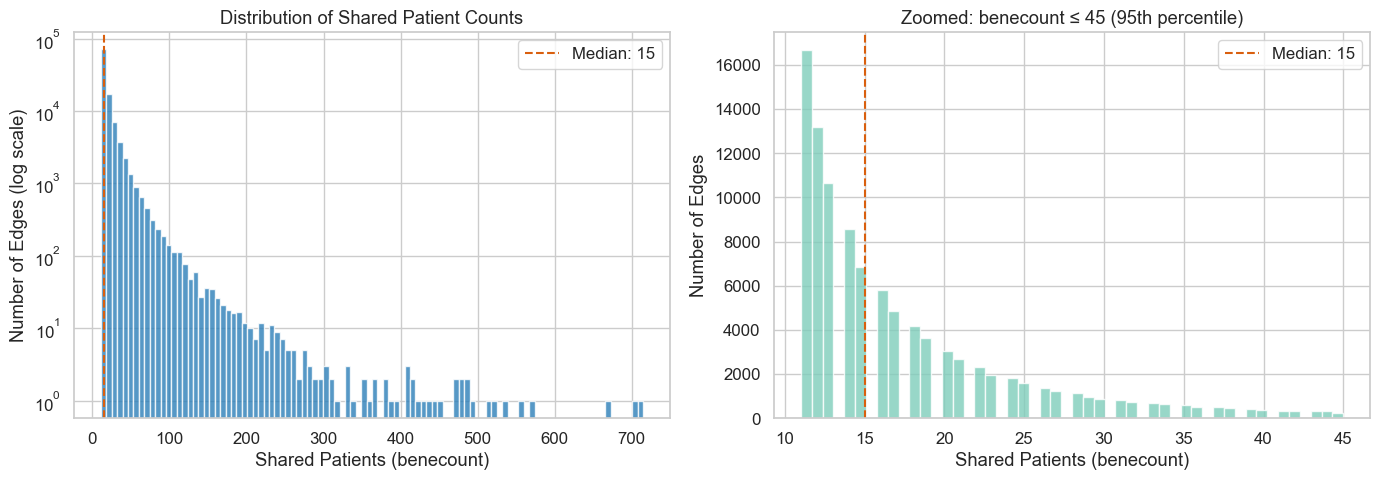

Shared patient count (benecount) summary:
count    105891.000000
mean         20.219178
std          18.177142
min          11.000000
25%          12.000000
50%          15.000000
75%          21.000000
max         715.000000

95th percentile: 45
99th percentile: 89


In [16]:
# -------------------------------------------------------------------
# 3a. Shared Patient Count Distribution (benecount)
# -------------------------------------------------------------------

# Ensure numeric
edges["benecount"] = pd.to_numeric(edges["benecount"], errors="coerce")
edges["paircount"] = pd.to_numeric(edges["paircount"], errors="coerce")
edges["samedaycount"] = pd.to_numeric(edges["samedaycount"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Full distribution (log scale)
axes[0].hist(edges["benecount"], bins=100, color=PROJECT_COLORS["primary"],
             edgecolor="white", alpha=0.8)
axes[0].set_yscale("log")
axes[0].set_xlabel("Shared Patients (benecount)")
axes[0].set_ylabel("Number of Edges (log scale)")
axes[0].set_title("Distribution of Shared Patient Counts")
axes[0].axvline(edges["benecount"].median(), color=PROJECT_COLORS["accent"],
                linestyle="--", label=f"Median: {edges['benecount'].median():.0f}")
axes[0].legend()

# Right: Zoomed to 95th percentile
p95 = edges["benecount"].quantile(0.95)
axes[1].hist(edges["benecount"][edges["benecount"] <= p95], bins=50,
             color=PROJECT_COLORS["secondary"], edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Shared Patients (benecount)")
axes[1].set_ylabel("Number of Edges")
axes[1].set_title(f"Zoomed: benecount ≤ {p95:.0f} (95th percentile)")
axes[1].axvline(edges["benecount"].median(), color=PROJECT_COLORS["accent"],
                linestyle="--", label=f"Median: {edges['benecount'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Shared patient count (benecount) summary:")
print(edges["benecount"].describe().to_string())
print(f"\n95th percentile: {p95:.0f}")
print(f"99th percentile: {edges['benecount'].quantile(0.99):.0f}")

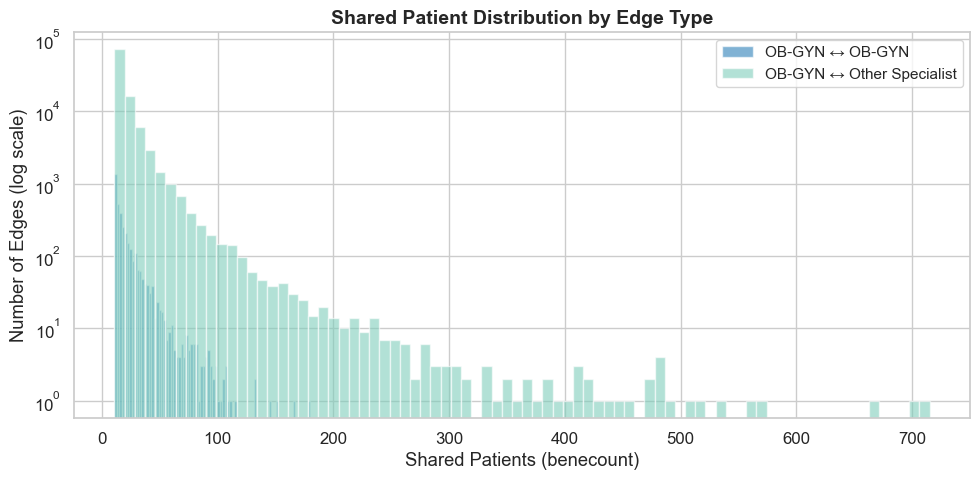


Benecount summary by edge type:
                count  mean   std   min   25%   50%   75%    max
edge_type                                                       
obgyn_obgyn    3751.0  20.5  14.6  11.0  12.0  15.0  22.0  180.0
obgyn_other  102140.0  20.2  18.3  11.0  12.0  15.0  21.0  715.0


In [17]:
# -------------------------------------------------------------------
# 3b. Edge Weight by Edge Type
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

for edge_type, color, label in [
    ("obgyn_obgyn", PROJECT_COLORS["obgyn_obgyn"], "OB-GYN ↔ OB-GYN"),
    ("obgyn_other", PROJECT_COLORS["obgyn_other"], "OB-GYN ↔ Other Specialist")
]:
    subset = edges[edges["edge_type"] == edge_type]["benecount"]
    ax.hist(subset, bins=80, alpha=0.6, color=color, label=label, edgecolor="white")

ax.set_yscale("log")
ax.set_xlabel("Shared Patients (benecount)")
ax.set_ylabel("Number of Edges (log scale)")
ax.set_title("Shared Patient Distribution by Edge Type", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Summary stats by edge type
print("\nBenecount summary by edge type:")
print(edges.groupby("edge_type")["benecount"].describe().round(1).to_string())

In [18]:
# -------------------------------------------------------------------
# EXPORT: Edge weight by type for Tableau side-by-side bar chart
# -------------------------------------------------------------------
# Bins shared patient counts into ranges, split by edge type.
# Tableau: Edge Type on Color, Patient Range on Rows, Edge Count on Columns.
# -------------------------------------------------------------------

edges_for_bins = edges[["edge_type", "benecount"]].copy()

bins = [0, 20, 30, 50, 100, 200, float("inf")]
labels = ["11-20", "21-30", "31-50", "51-100", "101-200", "201+"]
edges_for_bins["Patient Range"] = pd.cut(edges_for_bins["benecount"], bins=bins, labels=labels)

edge_weight_export = (
    edges_for_bins
    .groupby(["Patient Range", "edge_type"])
    .size()
    .reset_index(name="Edge Count")
)

edge_weight_export["Edge Type Label"] = edge_weight_export["edge_type"].map({
    "obgyn_obgyn": "OB-GYN to OB-GYN",
    "obgyn_other": "OB-GYN to Other Specialist"
})

edge_weight_export = edge_weight_export[["Patient Range", "Edge Type Label", "Edge Count"]]

edge_weight_export.to_csv(OUTPUT_DIR / "tableau_edge_weight_by_type.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'tableau_edge_weight_by_type.csv'}")
display(edge_weight_export)

Saved: ../data/outputs/tableau_edge_weight_by_type.csv


/var/folders/0d/xqmptt6x035b25m88r2ffc9m0000gn/T/ipykernel_4207/1993555061.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edges_for_bins


,Patient Range,Edge Type Label,Edge Count
0,11-20,OB-GYN to OB-GYN,2663
1,11-20,OB-GYN to Other Specialist,74747
2,21-30,OB-GYN to OB-GYN,556
3,21-30,OB-GYN to Other Specialist,15387
4,31-50,OB-GYN to OB-GYN,376
5,31-50,OB-GYN to Other Specialist,8021
6,51-100,OB-GYN to OB-GYN,140
7,51-100,OB-GYN to Other Specialist,3214
8,101-200,OB-GYN to OB-GYN,16
9,101-200,OB-GYN to Other Specialist,641


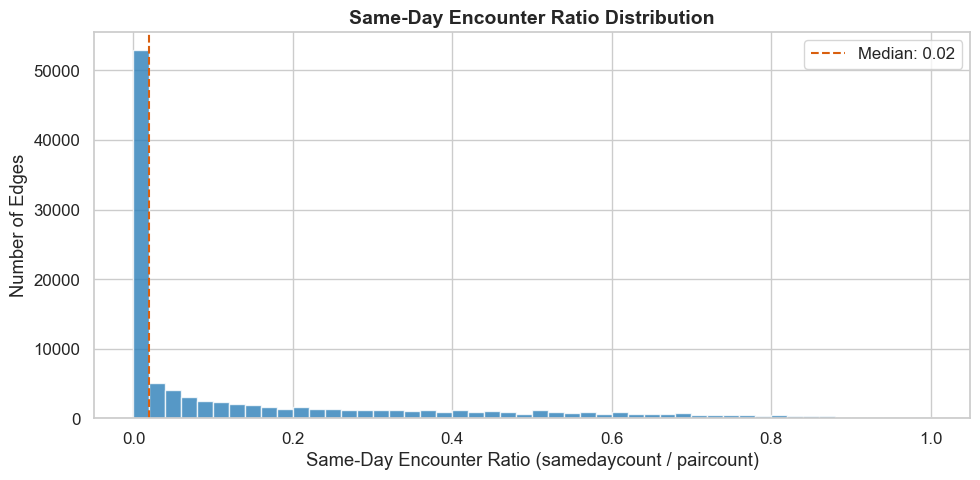

Same-day ratio summary:
count    105891.000
mean          0.154
std           0.233
min           0.000
25%           0.000
50%           0.020
75%           0.238
max           1.000

Edges with 100% same-day encounters: 165
Edges with 0% same-day encounters:   50,327


In [19]:
# -------------------------------------------------------------------
# 3c. Same-Day Encounters as Proportion of Total
# -------------------------------------------------------------------
# Same-day encounters suggest co-located or tightly coordinated care
# (e.g., same hospital, same clinic). A high same-day ratio may indicate
# co-practice rather than a referral relationship.
# -------------------------------------------------------------------

edges["sameday_ratio"] = edges["samedaycount"] / edges["paircount"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(edges["sameday_ratio"], bins=50, color=PROJECT_COLORS["primary"],
        edgecolor="white", alpha=0.8)
ax.set_xlabel("Same-Day Encounter Ratio (samedaycount / paircount)")
ax.set_ylabel("Number of Edges")
ax.set_title("Same-Day Encounter Ratio Distribution", fontsize=14, fontweight="bold")
ax.axvline(edges["sameday_ratio"].median(), color=PROJECT_COLORS["accent"],
            linestyle="--", label=f"Median: {edges['sameday_ratio'].median():.2f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Same-day ratio summary:")
print(edges["sameday_ratio"].describe().round(3).to_string())
print(f"\nEdges with 100% same-day encounters: {(edges['sameday_ratio'] == 1.0).sum():,}")
print(f"Edges with 0% same-day encounters:   {(edges['sameday_ratio'] == 0.0).sum():,}")

---

## 5. Network Degree Analysis

The **degree** of a provider is the number of other providers they share patients with. A high-degree OB-GYN is well-connected (coordinates with many specialists); a low-degree OB-GYN may practice in relative isolation. We compute degree separately for:

- **Total degree** — all connections (OB-GYN + other specialists)
- **OB-GYN degree** — connections to other OB-GYNs only

In [20]:
# -------------------------------------------------------------------
# 4a. Compute Degree for Each OB-GYN Provider
# -------------------------------------------------------------------

OBGYN_NPI_SET = set(providers["npi"])

# Total degree: count how many unique partners each OB-GYN has
# An OB-GYN can appear as npi1 or npi2
degree_counter = Counter()
obgyn_degree_counter = Counter()  # OB-GYN-to-OB-GYN only

for _, row in edges.iterrows():
    n1, n2 = row["npi1"], row["npi2"]
    is_obgyn1 = n1 in OBGYN_NPI_SET
    is_obgyn2 = n2 in OBGYN_NPI_SET
    
    # Count total degree for OB-GYN providers
    if is_obgyn1:
        degree_counter[n1] += 1
    if is_obgyn2:
        degree_counter[n2] += 1
    
    # Count OB-GYN-only degree
    if is_obgyn1 and is_obgyn2:
        obgyn_degree_counter[n1] += 1
        obgyn_degree_counter[n2] += 1

print(f"OB-GYN providers with at least one connection: {len(degree_counter):,}")
print(f"OB-GYN providers with at least one OB-GYN connection: {len(obgyn_degree_counter):,}")

# Providers in our provider list but NOT in the edge list (isolated)
connected_npis = set(degree_counter.keys())
isolated = OBGYN_NPI_SET - connected_npis
print(f"OB-GYN providers with NO connections (isolated): {len(isolated):,}")
print(f"  ({len(isolated)/len(OBGYN_NPI_SET)*100:.1f}% of all OB-GYNs)")

OB-GYN providers with at least one connection: 12,227
OB-GYN providers with at least one OB-GYN connection: 2,791
OB-GYN providers with NO connections (isolated): 48,195
  (79.8% of all OB-GYNs)


In [21]:
# -------------------------------------------------------------------
# 4b. Build Provider-Level Degree Table
# -------------------------------------------------------------------

degree_df = providers.copy()
degree_df["total_degree"] = degree_df["npi"].map(degree_counter).fillna(0).astype(int)
degree_df["obgyn_degree"] = degree_df["npi"].map(obgyn_degree_counter).fillna(0).astype(int)
degree_df["other_degree"] = degree_df["total_degree"] - degree_df["obgyn_degree"]

print("Degree statistics (all OB-GYN providers):")
print(degree_df[["total_degree", "obgyn_degree", "other_degree"]].describe().round(1).to_string())

Degree statistics (all OB-GYN providers):
       total_degree  obgyn_degree  other_degree
count       60422.0       60422.0       60422.0
mean            1.8           0.1           1.7
std            10.1           0.8           9.9
min             0.0           0.0           0.0
25%             0.0           0.0           0.0
50%             0.0           0.0           0.0
75%             0.0           0.0           0.0
max           770.0          25.0         762.0


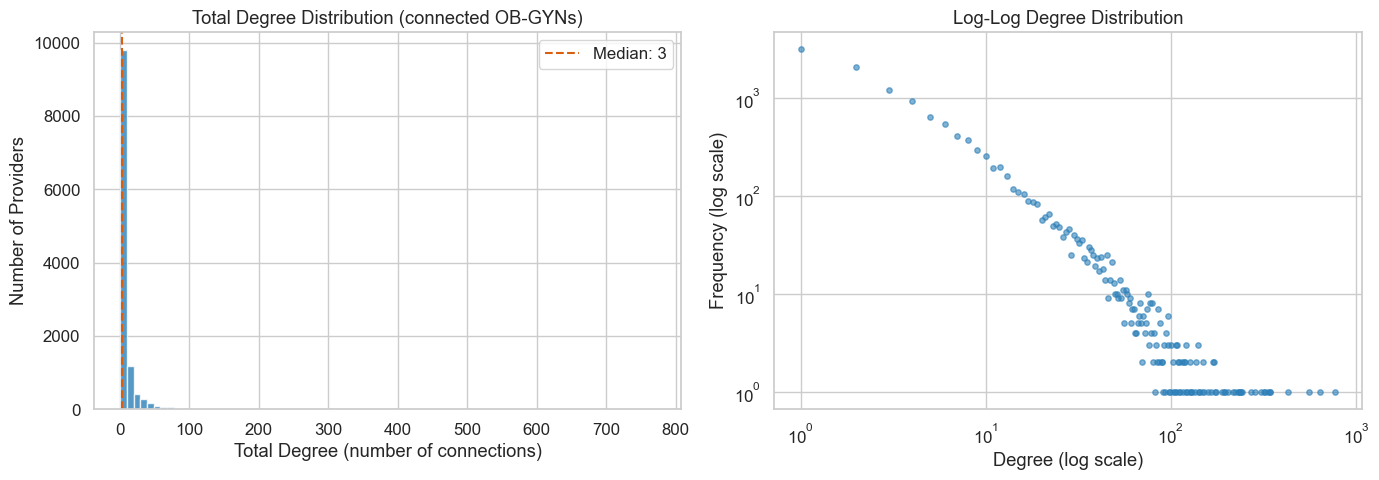


Connected OB-GYNs: 12,227
Median degree: 3
Mean degree: 9.0
Max degree: 770


In [22]:
# -------------------------------------------------------------------
# 4c. Degree Distribution Plot
# -------------------------------------------------------------------

connected = degree_df[degree_df["total_degree"] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram of total degree
axes[0].hist(connected["total_degree"], bins=80, color=PROJECT_COLORS["primary"],
             edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Total Degree (number of connections)")
axes[0].set_ylabel("Number of Providers")
axes[0].set_title("Total Degree Distribution (connected OB-GYNs)")
axes[0].axvline(connected["total_degree"].median(), color=PROJECT_COLORS["accent"],
                linestyle="--", label=f"Median: {connected['total_degree'].median():.0f}")
axes[0].legend()

# Right: Log-log degree distribution (power law check)
degree_values = connected["total_degree"].value_counts().sort_index()
axes[1].scatter(degree_values.index, degree_values.values,
                s=15, alpha=0.6, color=PROJECT_COLORS["primary"])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Degree (log scale)")
axes[1].set_ylabel("Frequency (log scale)")
axes[1].set_title("Log-Log Degree Distribution")

plt.tight_layout()
plt.show()

print(f"\nConnected OB-GYNs: {len(connected):,}")
print(f"Median degree: {connected['total_degree'].median():.0f}")
print(f"Mean degree: {connected['total_degree'].mean():.1f}")
print(f"Max degree: {connected['total_degree'].max()}")

In [23]:
# -------------------------------------------------------------------
# 4d. Top 15 Most Connected OB-GYN Providers
# -------------------------------------------------------------------

top15 = degree_df.nlargest(15, "total_degree")[
    ["npi", "first_name", "last_name", "subspecialty", "city", "state",
     "total_degree", "obgyn_degree", "other_degree"]
].reset_index(drop=True)

print("Top 15 Most Connected OB-GYN Providers:")
display(top15)

Top 15 Most Connected OB-GYN Providers:


,npi,first_name,last_name,subspecialty,city,state,total_degree,obgyn_degree,other_degree
0,1386725042,TERESITA,ANGTUACO,Gynecology,LITTLE ROCK,AR,770,8,762
1,1548451727,MARY,LOWRY,Obstetrics & Gynecology,DENVER,CO,639,0,639
2,1134104169,KARL,METZ,Gynecology,FORT WALTON BEACH,FL,557,2,555
3,1578626529,ANGEL,ROSAS-ACEVEDO,Obstetrics & Gynecology,BECKLEY,WV,429,25,404
4,1306906854,ZAHID,ASLAM,Obstetrics & Gynecology,ELKTON,MD,342,3,339
5,1164405445,DANIELLE,MYERS,Obstetrics,MODESTO,CA,341,2,339
6,1104910082,DANIEL,KATZ,Female Pelvic Medicine and Reconstructive Surgery,POUGHKEEPSIE,NY,335,0,335
7,1265745053,AMINE,KHACHANI,Obstetrics & Gynecology,HOMESTEAD,FL,324,0,324
8,1689813073,DEREK,TENNENHOUSE,Obstetrics & Gynecology,CARMEL,IN,319,0,319
9,1326154279,PAULA,VAUGHAN,Obstetrics & Gynecology,GROTON,MA,305,4,301


In [24]:
# -------------------------------------------------------------------
# 4e. Degree by State — Are some states more connected?
# -------------------------------------------------------------------

state_degree = degree_df.groupby("state").agg(
    n_providers=("npi", "count"),
    n_connected=("total_degree", lambda x: (x > 0).sum()),
    mean_degree=("total_degree", "mean"),
    median_degree=("total_degree", "median"),
    max_degree=("total_degree", "max")
).sort_values("n_providers", ascending=False)

state_degree["pct_connected"] = (
    state_degree["n_connected"] / state_degree["n_providers"] * 100
).round(1)

print("State-level network summary (top 15 by provider count):")
display(state_degree.head(15))

State-level network summary (top 15 by provider count):


,n_providers,n_connected,mean_degree,median_degree,max_degree,pct_connected
state,,,,,,
CA,6655,1075,1.432156,0.0,341,16.2
TX,4611,823,1.423336,0.0,230,17.8
NY,4474,818,1.576442,0.0,335,18.3
FL,3628,781,2.984840,0.0,557,21.5
PA,2642,633,2.278955,0.0,234,24.0
IL,2586,502,1.401779,0.0,135,19.4
MI,2125,408,1.097882,0.0,77,19.2
OH,2081,440,1.563671,0.0,222,21.1
NC,2010,423,2.100498,0.0,126,21.0


In [25]:
# -------------------------------------------------------------------
# EXPORT: State-level degree metrics for Tableau choropleth map
# -------------------------------------------------------------------
# Color: Pct Connected | Tooltip: all other metrics
# Filter to 50 states + DC, fill missing states with 0.
# -------------------------------------------------------------------

US_STATES_LIST = [
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "DC", "FL",
    "GA", "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME",
    "MD", "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH",
    "NJ", "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI",
    "SC", "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY"
]

state_degree_export = state_degree.reset_index().rename(columns={"state": "State"})
state_degree_export["pct_isolated"] = (100 - state_degree_export["pct_connected"]).round(1)

# Keep only US states
all_states_df = pd.DataFrame({"State": US_STATES_LIST})
state_degree_export = all_states_df.merge(state_degree_export, on="State", how="left")

# Fill missing states with zeros
fill_cols = ["n_providers", "n_connected", "mean_degree", "median_degree",
             "max_degree", "pct_connected", "pct_isolated"]
for col in fill_cols:
    state_degree_export[col] = state_degree_export[col].fillna(0)

state_degree_export = state_degree_export[
    ["State", "n_providers", "n_connected", "pct_connected", "pct_isolated",
     "mean_degree", "median_degree", "max_degree"]
].round(1)

state_degree_export.columns = [
    "State", "Total OB-GYNs", "Connected OB-GYNs", "Pct Connected",
    "Pct Isolated", "Mean Degree", "Median Degree", "Max Degree"
]

state_degree_export.to_csv(OUTPUT_DIR / "tableau_state_degree_map.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'tableau_state_degree_map.csv'}")
print(f"  {len(state_degree_export)} states")
display(state_degree_export)

Saved: ../data/outputs/tableau_state_degree_map.csv
  51 states


,State,Total OB-GYNs,Connected OB-GYNs,Pct Connected,Pct Isolated,Mean Degree,Median Degree,Max Degree
0,AL,706,293,41.5,58.5,4.7,0.0,158
1,AK,141,14,9.9,90.1,1.7,0.0,78
2,AZ,1073,135,12.6,87.4,1.5,0.0,216
3,AR,365,136,37.3,62.7,5.7,0.0,770
4,CA,6655,1075,16.2,83.8,1.4,0.0,341
5,CO,1177,130,11.0,89.0,1.1,0.0,639
6,CT,956,292,30.5,69.5,1.4,0.0,77
7,DE,190,54,28.4,71.6,5.0,0.0,141
8,DC,338,20,5.9,94.1,0.3,0.0,27
9,FL,3628,781,21.5,78.5,3.0,0.0,557


---

## 6. Morbidity Rate Exploration

Exploring the geographic variation in maternal morbidity rates from the CDC WONDER data.

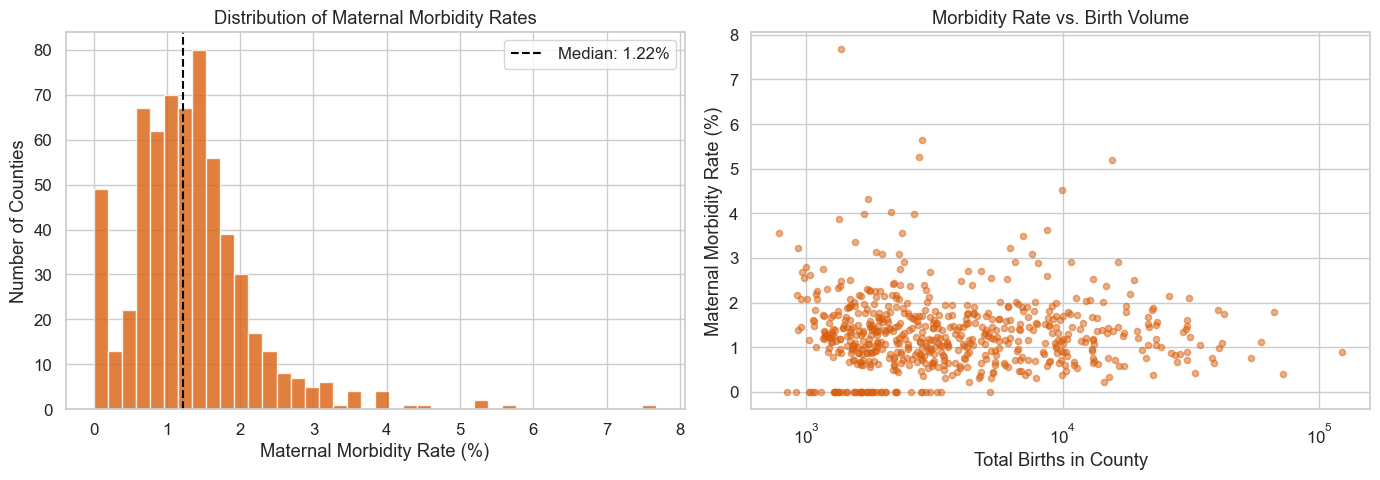

Morbidity rate summary (as percentage):
count    626.000
mean       1.305
std        0.838
min        0.000
25%        0.792
50%        1.219
75%        1.683
max        7.681


In [26]:
# -------------------------------------------------------------------
# 5a. Morbidity Rate Distribution
# -------------------------------------------------------------------

# Ensure numeric
morbidity["morbidity_rate"] = pd.to_numeric(morbidity["morbidity_rate"], errors="coerce")
morbidity["total_births"] = pd.to_numeric(morbidity["total_births"], errors="coerce")
morbidity["morbidity_births"] = pd.to_numeric(morbidity["morbidity_births"], errors="coerce")

valid_rates = morbidity[morbidity["morbidity_rate"].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram of morbidity rates
axes[0].hist(valid_rates["morbidity_rate"] * 100, bins=40,
             color=PROJECT_COLORS["accent"], edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Maternal Morbidity Rate (%)")
axes[0].set_ylabel("Number of Counties")
axes[0].set_title("Distribution of Maternal Morbidity Rates")
axes[0].axvline(valid_rates["morbidity_rate"].median() * 100,
                color="black", linestyle="--",
                label=f"Median: {valid_rates['morbidity_rate'].median()*100:.2f}%")
axes[0].legend()

# Right: Rate vs. total births (size = volume)
axes[1].scatter(valid_rates["total_births"], valid_rates["morbidity_rate"] * 100,
                s=20, alpha=0.5, color=PROJECT_COLORS["accent"])
axes[1].set_xlabel("Total Births in County")
axes[1].set_ylabel("Maternal Morbidity Rate (%)")
axes[1].set_title("Morbidity Rate vs. Birth Volume")
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()

print("Morbidity rate summary (as percentage):")
print((valid_rates["morbidity_rate"] * 100).describe().round(3).to_string())

In [27]:
# -------------------------------------------------------------------
# 5b. Top and Bottom Counties by Morbidity Rate
# -------------------------------------------------------------------

# Only include counties with meaningful birth volume (>= 500 births)
substantial = valid_rates[valid_rates["total_births"] >= 500].copy()

print(f"Counties with >= 500 births: {len(substantial):,} (of {len(valid_rates):,} total)")

print(f"\n--- Top 10 Highest Morbidity Rates (counties with >= 500 births) ---")
display(substantial.nlargest(10, "morbidity_rate")[
    ["county_name", "fips", "state", "total_births", "morbidity_births", "morbidity_rate"]
].reset_index(drop=True))

print(f"\n--- Top 10 Lowest Morbidity Rates (counties with >= 500 births) ---")
display(substantial.nsmallest(10, "morbidity_rate")[
    ["county_name", "fips", "state", "total_births", "morbidity_births", "morbidity_rate"]
].reset_index(drop=True))

Counties with >= 500 births: 626 (of 626 total)

--- Top 10 Highest Morbidity Rates (counties with >= 500 births) ---


,county_name,fips,state,total_births,morbidity_births,morbidity_rate
0,"Schuylkill County, PA",42107,PA,1367,105.0,0.076811
1,"Dona Ana County, NM",35013,NM,2839,160.0,0.056358
2,"Benton County, WA",53005,WA,2759,145.0,0.052555
3,"Suffolk County, NY",36103,NY,15559,809.0,0.051996
4,"Erie County, NY",36029,NY,9916,448.0,0.045180
5,"Carroll County, MD",24013,MD,1737,75.0,0.043178
6,"Niagara County, NY",36063,NY,2139,86.0,0.040206
7,"Beaver County, PA",42007,PA,1676,67.0,0.039976
8,"Cass County, ND",38017,ND,2639,105.0,0.039788
9,"Chautauqua County, NY",36013,NY,1345,52.0,0.038662



--- Top 10 Lowest Morbidity Rates (counties with >= 500 births) ---


,county_name,fips,state,total_births,morbidity_births,morbidity_rate
0,"Houston County, AL",01069,AL,1333,0.0,0.0
1,"Mohave County, AZ",04015,AZ,1802,0.0,0.0
2,"Saline County, AR",05125,AR,1326,0.0,0.0
3,"Imperial County, CA",06025,CA,2939,0.0,0.0
4,"Kings County, CA",06031,CA,2248,0.0,0.0
5,"Shasta County, CA",06089,CA,2048,0.0,0.0
6,"Charlotte County, FL",12015,FL,1037,0.0,0.0
7,"Citrus County, FL",12017,FL,1064,0.0,0.0
8,"Bartow County, GA",13015,GA,1338,0.0,0.0
9,"Fayette County, GA",13113,GA,911,0.0,0.0


In [29]:
# -------------------------------------------------------------------
# EXPORT: Top morbidity counties for Tableau table
# -------------------------------------------------------------------
# Filtered to counties with >= 500 births for stable rates.
# -------------------------------------------------------------------

top_morb_export = substantial.nlargest(20, "morbidity_rate")[
    ["county_name", "state", "fips", "total_births", "morbidity_births", "morbidity_rate"]
].copy()

top_morb_export["morbidity_rate_pct"] = (top_morb_export["morbidity_rate"] * 100).round(2)

top_morb_export = top_morb_export.rename(columns={
    "county_name": "County",
    "state": "State",
    "fips": "FIPS",
    "total_births": "Total Births",
    "morbidity_births": "Morbidity Births",
    "morbidity_rate_pct": "Morbidity Rate (%)"
}).drop(columns=["morbidity_rate"]).reset_index(drop=True)

top_morb_export.to_csv(OUTPUT_DIR / "tableau_top_morbidity_counties.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'tableau_top_morbidity_counties.csv'}")
print(f"  {len(top_morb_export)} counties")
display(top_morb_export)

Saved: ../data/outputs/tableau_top_morbidity_counties.csv
  20 counties


,County,State,FIPS,Total Births,Morbidity Births,Morbidity Rate (%)
0,"Schuylkill County, PA",PA,42107,1367,105.0,7.68
1,"Dona Ana County, NM",NM,35013,2839,160.0,5.64
2,"Benton County, WA",WA,53005,2759,145.0,5.26
3,"Suffolk County, NY",NY,36103,15559,809.0,5.20
4,"Erie County, NY",NY,36029,9916,448.0,4.52
5,"Carroll County, MD",MD,24013,1737,75.0,4.32
6,"Niagara County, NY",NY,36063,2139,86.0,4.02
7,"Beaver County, PA",PA,42007,1676,67.0,4.00
8,"Cass County, ND",ND,38017,2639,105.0,3.98
9,"Chautauqua County, NY",NY,36013,1345,52.0,3.87


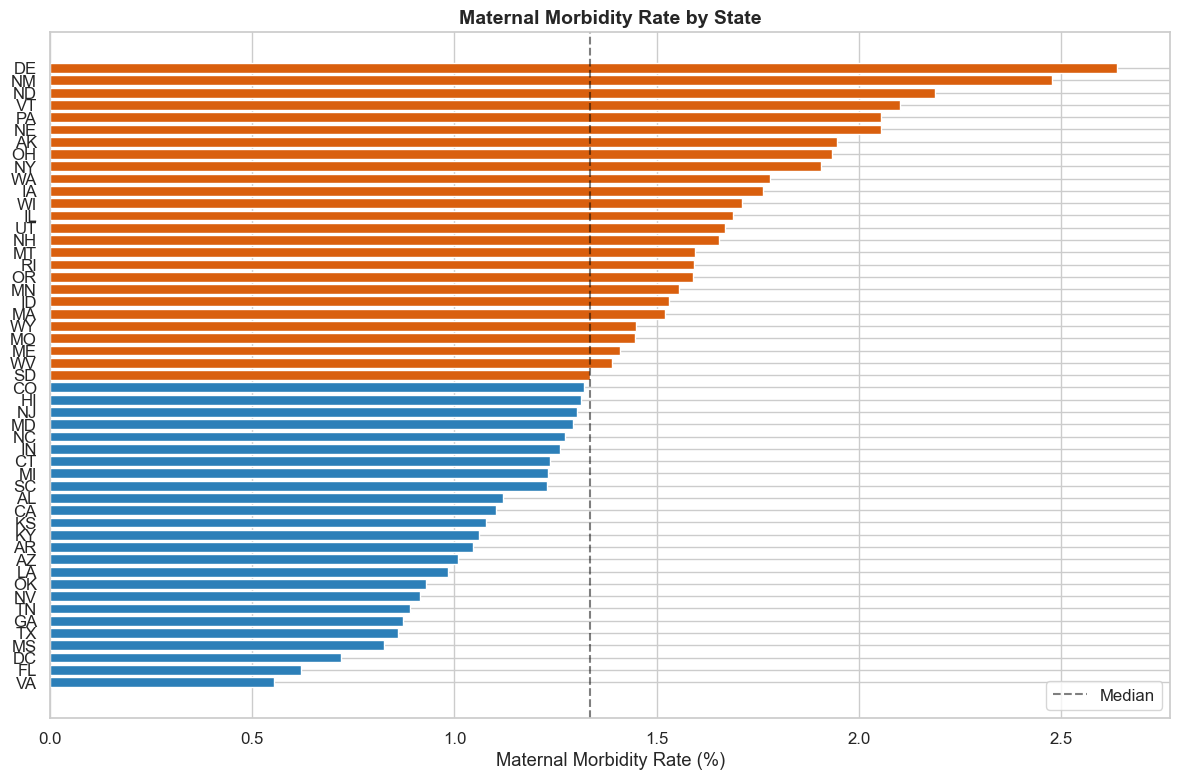

In [28]:
# -------------------------------------------------------------------
# 5c. Morbidity Rates by State (aggregated)
# -------------------------------------------------------------------

state_morbidity = valid_rates.groupby("state").agg(
    total_births=("total_births", "sum"),
    morbidity_births=("morbidity_births", "sum"),
    n_counties=("fips", "count")
).reset_index()

state_morbidity["morbidity_rate"] = (
    state_morbidity["morbidity_births"] / state_morbidity["total_births"]
)

state_morbidity = state_morbidity.sort_values("morbidity_rate", ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors = [PROJECT_COLORS["accent"] if r >= state_morbidity["morbidity_rate"].median()
          else PROJECT_COLORS["primary"] for r in state_morbidity["morbidity_rate"]]

ax.barh(state_morbidity["state"][::-1],
        state_morbidity["morbidity_rate"].values[::-1] * 100,
        color=colors[::-1], edgecolor="white")
ax.axvline(state_morbidity["morbidity_rate"].median() * 100,
           color="black", linestyle="--", alpha=0.5, label="Median")
ax.set_xlabel("Maternal Morbidity Rate (%)")
ax.set_title("Maternal Morbidity Rate by State", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [30]:
# -------------------------------------------------------------------
# EXPORT: State-level morbidity for Tableau choropleth map
# -------------------------------------------------------------------
# Color: Morbidity Rate | Tooltip: births, morbidity births, counties
# All 50 states + DC, missing filled with 0.
# -------------------------------------------------------------------

US_STATES_LIST = [
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "DC", "FL",
    "GA", "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME",
    "MD", "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH",
    "NJ", "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI",
    "SC", "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY"
]

state_morb_export = state_morbidity.copy()
state_morb_export["morbidity_rate_pct"] = (state_morb_export["morbidity_rate"] * 100).round(2)

all_states_df = pd.DataFrame({"state": US_STATES_LIST})
state_morb_export = all_states_df.merge(state_morb_export, on="state", how="left")

fill_cols = ["total_births", "morbidity_births", "n_counties", "morbidity_rate", "morbidity_rate_pct"]
for col in fill_cols:
    state_morb_export[col] = state_morb_export[col].fillna(0)

state_morb_export = state_morb_export.rename(columns={
    "state": "State",
    "total_births": "Total Births",
    "morbidity_births": "Morbidity Births",
    "n_counties": "Counties Reporting",
    "morbidity_rate_pct": "Morbidity Rate (%)"
}).drop(columns=["morbidity_rate"])

state_morb_export["Total Births"] = state_morb_export["Total Births"].astype(int)
state_morb_export["Morbidity Births"] = state_morb_export["Morbidity Births"].astype(int)
state_morb_export["Counties Reporting"] = state_morb_export["Counties Reporting"].astype(int)

state_morb_export.to_csv(OUTPUT_DIR / "tableau_state_morbidity_map.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'tableau_state_morbidity_map.csv'}")
print(f"  {len(state_morb_export)} states")
display(state_morb_export)

Saved: ../data/outputs/tableau_state_morbidity_map.csv
  51 states


,State,Total Births,Morbidity Births,Counties Reporting,Morbidity Rate (%)
0,AL,59151,662,13,1.12
1,AK,11209,218,2,1.94
2,AZ,84520,853,10,1.01
3,AR,38274,400,7,1.05
4,CA,488827,5394,36,1.10
5,CO,66613,880,12,1.32
6,CT,36015,445,8,1.24
7,DE,10992,290,3,2.64
8,DC,9858,71,1,0.72
9,FL,225022,1398,34,0.62


---

## 7. Provider Density vs. Morbidity — Early Correlation

Do states with more OB-GYN providers (relative to births) tend to have better maternal outcomes? This is an early, state-level exploration. A more granular county-level analysis will follow in Phase 5.

**Metric:** OB-GYN providers per 10,000 births

In [31]:
# -------------------------------------------------------------------
# 6a. Build State-Level Comparison Table
# -------------------------------------------------------------------

# Provider counts by state
state_providers = providers.groupby("state").size().reset_index(name="n_obgyn")

# Merge with morbidity
state_comparison = state_morbidity.merge(state_providers, on="state", how="inner")

# Compute provider density
state_comparison["obgyn_per_10k_births"] = (
    state_comparison["n_obgyn"] / state_comparison["total_births"] * 10_000
)

# Merge network connectivity (mean degree by state)
state_connectivity = degree_df.groupby("state")["total_degree"].mean().reset_index(
    name="mean_degree"
)
state_comparison = state_comparison.merge(state_connectivity, on="state", how="left")

print(f"State comparison table: {len(state_comparison)} states")
display(state_comparison.sort_values("morbidity_rate", ascending=False).head(10))

State comparison table: 51 states


,state,total_births,morbidity_births,n_counties,morbidity_rate,n_obgyn,obgyn_per_10k_births,mean_degree
0,DE,10992,290.0,3,0.026383,190,172.852984,4.994737
1,NM,24692,612.0,6,0.024785,336,136.076462,1.092262
2,ND,11383,249.0,2,0.021875,105,92.242818,1.342857
3,VT,5756,121.0,2,0.021022,134,232.800556,2.656716
4,PA,139409,2864.0,32,0.020544,2642,189.514307,2.278955
5,NE,26589,546.0,4,0.020535,337,126.744142,3.062315
6,AK,11209,218.0,2,0.019449,141,125.791774,1.695035
7,OH,138085,2670.0,29,0.019336,2081,150.704276,1.563671
8,NY,234283,4468.0,29,0.019071,4474,190.965627,1.576442
9,WA,90505,1610.0,13,0.017789,1358,150.046959,0.910162


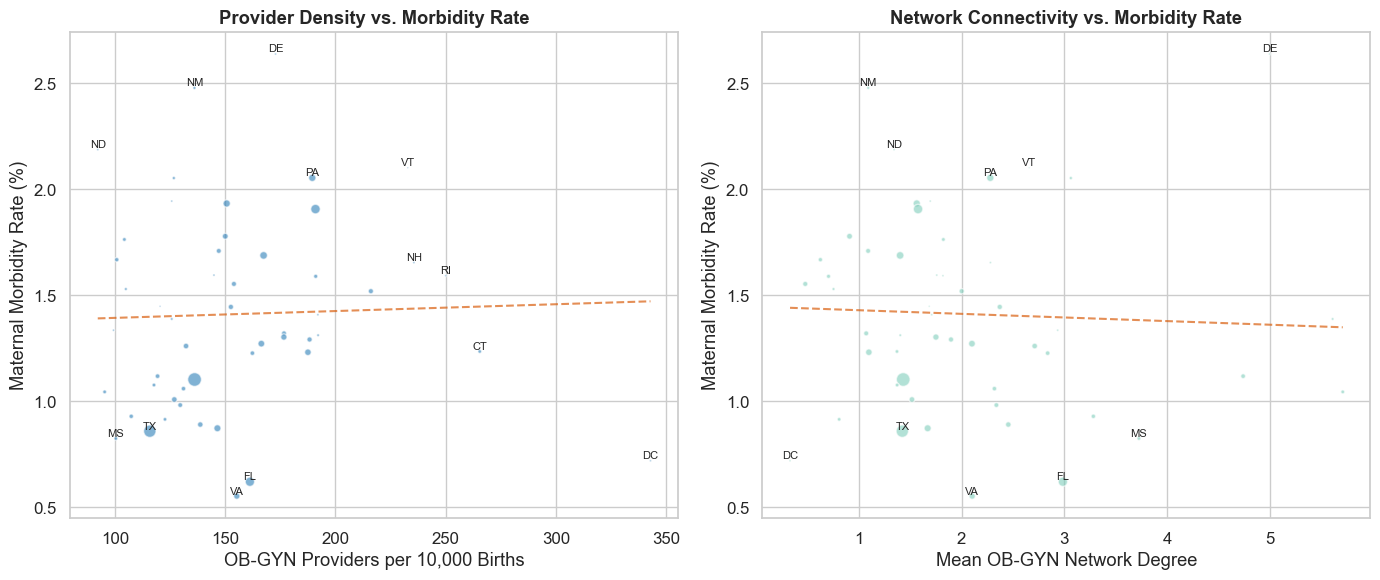

In [32]:
# -------------------------------------------------------------------
# 6b. Scatter: Provider Density vs. Morbidity Rate
# -------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Provider density vs. morbidity
ax = axes[0]
ax.scatter(state_comparison["obgyn_per_10k_births"],
           state_comparison["morbidity_rate"] * 100,
           s=state_comparison["total_births"] / 5000,  # size = birth volume
           alpha=0.6, color=PROJECT_COLORS["primary"], edgecolors="white")

# Label outlier states
for _, row in state_comparison.iterrows():
    if (row["morbidity_rate"] > state_comparison["morbidity_rate"].quantile(0.9) or
        row["morbidity_rate"] < state_comparison["morbidity_rate"].quantile(0.1) or
        row["obgyn_per_10k_births"] > state_comparison["obgyn_per_10k_births"].quantile(0.9)):
        ax.annotate(row["state"], (row["obgyn_per_10k_births"], row["morbidity_rate"] * 100),
                    fontsize=8, ha="center", va="bottom")

# Add trend line
from numpy.polynomial import polynomial as P
x = state_comparison["obgyn_per_10k_births"].values
y = state_comparison["morbidity_rate"].values * 100
mask = np.isfinite(x) & np.isfinite(y)
if mask.sum() > 2:
    coeffs = P.polyfit(x[mask], y[mask], 1)
    x_fit = np.linspace(x[mask].min(), x[mask].max(), 100)
    y_fit = P.polyval(x_fit, coeffs)
    ax.plot(x_fit, y_fit, color=PROJECT_COLORS["accent"], linestyle="--", alpha=0.7)

ax.set_xlabel("OB-GYN Providers per 10,000 Births")
ax.set_ylabel("Maternal Morbidity Rate (%)")
ax.set_title("Provider Density vs. Morbidity Rate", fontweight="bold")

# Right: Mean network degree vs. morbidity
ax = axes[1]
ax.scatter(state_comparison["mean_degree"],
           state_comparison["morbidity_rate"] * 100,
           s=state_comparison["total_births"] / 5000,
           alpha=0.6, color=PROJECT_COLORS["secondary"], edgecolors="white")

for _, row in state_comparison.iterrows():
    if (row["morbidity_rate"] > state_comparison["morbidity_rate"].quantile(0.9) or
        row["morbidity_rate"] < state_comparison["morbidity_rate"].quantile(0.1)):
        ax.annotate(row["state"], (row["mean_degree"], row["morbidity_rate"] * 100),
                    fontsize=8, ha="center", va="bottom")

x2 = state_comparison["mean_degree"].values
mask2 = np.isfinite(x2) & np.isfinite(y)
if mask2.sum() > 2:
    coeffs2 = P.polyfit(x2[mask2], y[mask2], 1)
    x_fit2 = np.linspace(x2[mask2].min(), x2[mask2].max(), 100)
    y_fit2 = P.polyval(x_fit2, coeffs2)
    ax.plot(x_fit2, y_fit2, color=PROJECT_COLORS["accent"], linestyle="--", alpha=0.7)

ax.set_xlabel("Mean OB-GYN Network Degree")
ax.set_ylabel("Maternal Morbidity Rate (%)")
ax.set_title("Network Connectivity vs. Morbidity Rate", fontweight="bold")

plt.tight_layout()
plt.show()

In [34]:
# -------------------------------------------------------------------
# EXPORT: State-level provider density vs morbidity for Tableau scatter
# -------------------------------------------------------------------
# X: OB-GYN per 10K Births | Y: Morbidity Rate (%)
# Size: Total Births | Label: State
# -------------------------------------------------------------------

scatter_export = state_comparison[[
    "state", "n_obgyn", "total_births", "morbidity_births",
    "morbidity_rate", "obgyn_per_10k_births", "mean_degree"
]].copy()

scatter_export["Morbidity Rate (%)"] = (scatter_export["morbidity_rate"] * 100).round(2)

scatter_export = scatter_export.rename(columns={
    "state": "State",
    "n_obgyn": "Total OB-GYNs",
    "total_births": "Total Births",
    "morbidity_births": "Morbidity Births",
    "obgyn_per_10k_births": "OB-GYN per 10K Births",
    "mean_degree": "Mean Degree"
}).drop(columns=["morbidity_rate"])

scatter_export["OB-GYN per 10K Births"] = scatter_export["OB-GYN per 10K Births"].round(1)
scatter_export["Mean Degree"] = scatter_export["Mean Degree"].round(2)

scatter_export.to_csv(OUTPUT_DIR / "tableau_density_vs_morbidity_scatter.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'tableau_density_vs_morbidity_scatter.csv'}")
print(f"  {len(scatter_export)} states")
display(scatter_export)

Saved: ../data/outputs/tableau_density_vs_morbidity_scatter.csv
  51 states


,State,Total OB-GYNs,Total Births,Morbidity Births,OB-GYN per 10K Births,Mean Degree,Morbidity Rate (%)
0,DE,190,10992,290.0,172.9,4.99,2.64
1,NM,336,24692,612.0,136.1,1.09,2.48
2,ND,105,11383,249.0,92.2,1.34,2.19
3,VT,134,5756,121.0,232.8,2.66,2.10
4,PA,2642,139409,2864.0,189.5,2.28,2.05
5,NE,337,26589,546.0,126.7,3.06,2.05
6,AK,141,11209,218.0,125.8,1.70,1.94
7,OH,2081,138085,2670.0,150.7,1.56,1.93
8,NY,4474,234283,4468.0,191.0,1.58,1.91
9,WA,1358,90505,1610.0,150.0,0.91,1.78


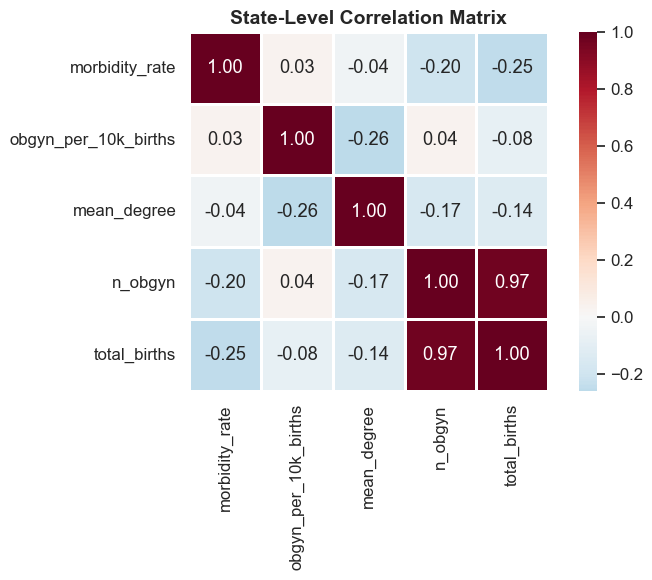

Provider Density vs. Morbidity Rate: r = 0.034, p = 0.8124
Mean Network Degree vs. Morbidity Rate: r = -0.045, p = 0.7552


In [33]:
# -------------------------------------------------------------------
# 6c. Correlation Analysis
# -------------------------------------------------------------------

corr_cols = ["morbidity_rate", "obgyn_per_10k_births", "mean_degree",
             "n_obgyn", "total_births"]
corr_matrix = state_comparison[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=1, ax=ax)
ax.set_title("State-Level Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Specific correlations of interest
from scipy import stats

for var, label in [("obgyn_per_10k_births", "Provider Density"),
                    ("mean_degree", "Mean Network Degree")]:
    valid = state_comparison[[var, "morbidity_rate"]].dropna()
    r, p = stats.pearsonr(valid[var], valid["morbidity_rate"])
    print(f"{label} vs. Morbidity Rate: r = {r:.3f}, p = {p:.4f}")

---

## 8. Key Findings Summary

In [35]:
# -------------------------------------------------------------------
# SUMMARY
# -------------------------------------------------------------------

print("=" * 75)
print("PHASE 3 — EXPLORATORY DATA ANALYSIS SUMMARY")
print("=" * 75)

print(f"\n--- Provider Overview ---")
print(f"  Total OB-GYN providers: {len(providers):,}")
print(f"  Subspecialties: {providers['subspecialty'].nunique()}")
print(f"  States/territories: {providers['state'].nunique()}")
top_spec = providers['subspecialty'].value_counts().iloc[0]
top_spec_name = providers['subspecialty'].value_counts().index[0]
print(f"  Most common subspecialty: {top_spec_name} ({top_spec:,}, "
      f"{top_spec/len(providers)*100:.1f}%)")

print(f"\n--- Non-OB-GYN Providers ---")
print(f"  Total non-OB-GYN providers: {len(other_providers):,}")
print(f"    Individuals:    {len(indiv_providers):,}")
print(f"    Organizations:  {len(org_providers):,}")
print(f"  Distinct individual classifications: {len(indiv_class_counts)}")
top_other = indiv_providers['classification'].value_counts().iloc[0]
top_other_name = indiv_providers['classification'].value_counts().index[0]
print(f"  Most common individual classification: {top_other_name} ({top_other:,})")

print(f"\n--- Network Overview (individual-to-individual only) ---")
print(f"  Total edges (all):        {len(edges_all):,}")
print(f"  Individual-only edges:    {len(edges):,}")
print(f"  OB-GYN to OB-GYN:        {(edges['edge_type']=='obgyn_obgyn').sum():,}")
print(f"  OB-GYN to Other:         {(edges['edge_type']=='obgyn_other').sum():,}")
print(f"  Median shared patients:   {edges['benecount'].median():.0f}")
print(f"  Connected OB-GYNs:        {len(connected):,} "
      f"({len(connected)/len(providers)*100:.1f}%)")
print(f"  Isolated OB-GYNs:         {len(isolated):,} "
      f"({len(isolated)/len(providers)*100:.1f}%)")
print(f"  Median degree (connected): {connected['total_degree'].median():.0f}")

print(f"\n--- Morbidity Overview ---")
print(f"  Counties with morbidity data: {len(valid_rates):,}")
print(f"  Median morbidity rate: {valid_rates['morbidity_rate'].median()*100:.2f}%")
print(f"  Range: {valid_rates['morbidity_rate'].min()*100:.2f}% - "
      f"{valid_rates['morbidity_rate'].max()*100:.2f}%")

print(f"\n--- Key Observations ---")
print(f"  1. 98%+ of OB-GYN connections are cross-specialty.")
print(f"  2. Non-OB-GYN side includes {len(org_providers):,} organizations — excluded")
print(f"     from network analysis (individual-to-individual only).")
print(f"  3. Most OB-GYNs have few connections; some hubs are highly connected.")
print(f"  4. {len(isolated):,} OB-GYNs ({len(isolated)/len(OBGYN_NPI_SET)*100:.1f}%) are isolated.")
print(f"  5. State-level correlations provide early signals for Phase 5.")

print(f"\n{'='*75}")
print(f"Ready to proceed to Phase 4: Network Analysis (04_network_analysis.ipynb)")

PHASE 3 — EXPLORATORY DATA ANALYSIS SUMMARY

--- Provider Overview ---
  Total OB-GYN providers: 60,422
  Subspecialties: 10
  States/territories: 97
  Most common subspecialty: Obstetrics & Gynecology (48,586, 80.4%)

--- Non-OB-GYN Providers ---
  Total non-OB-GYN providers: 46,527
    Individuals:    37,114
    Organizations:  8,031
  Distinct individual classifications: 81
  Most common individual classification: Radiology (11,389)

--- Network Overview (individual-to-individual only) ---
  Total edges (all):        243,052
  Individual-only edges:    105,891
  OB-GYN to OB-GYN:        3,751
  OB-GYN to Other:         102,140
  Median shared patients:   15
  Connected OB-GYNs:        12,227 (20.2%)
  Isolated OB-GYNs:         48,195 (79.8%)
  Median degree (connected): 3

--- Morbidity Overview ---
  Counties with morbidity data: 626
  Median morbidity rate: 1.22%
  Range: 0.00% - 7.68%

--- Key Observations ---
  1. 98%+ of OB-GYN connections are cross-specialty.
  2. Non-OB-GYN s

In [36]:
# -------------------------------------------------------------------
# EXPORT: Key project numbers for Tableau summary table
# -------------------------------------------------------------------

cross_specialty_pct = round((edges["edge_type"] == "obgyn_other").sum() / len(edges) * 100, 1)

summary_rows = [
    {"Metric": "Total OB-GYN Providers", "Value": f"{len(providers):,}"},
    {"Metric": "States Covered", "Value": "51"},
    {"Metric": "Isolated OB-GYNs", "Value": f"{len(isolated):,} ({len(isolated)/len(OBGYN_NPI_SET)*100:.1f}%)"},
    {"Metric": "Individual-to-Individual Connections", "Value": f"{len(edges):,}"},
    {"Metric": "Cross-Specialty Connections", "Value": f"{cross_specialty_pct}%"},
    {"Metric": "Non-OB-GYN Specialist Types", "Value": f"{indiv_providers['classification'].nunique()}"},
    {"Metric": "Top Non-OB-GYN Specialist", "Value": f"Radiology ({indiv_providers['classification'].value_counts().iloc[0]:,})"},
    {"Metric": "Counties with Morbidity Data", "Value": f"{len(valid_rates):,}"},
    {"Metric": "Median Morbidity Rate", "Value": f"{valid_rates['morbidity_rate'].median()*100:.2f}%"},
]

summary_export = pd.DataFrame(summary_rows)
summary_export.to_csv(OUTPUT_DIR / "tableau_key_numbers_summary.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'tableau_key_numbers_summary.csv'}")
display(summary_export)

Saved: ../data/outputs/tableau_key_numbers_summary.csv


,Metric,Value
0,Total OB-GYN Providers,"60,422"
1,States Covered,51
2,Isolated OB-GYNs,"48,195 (79.8%)"
3,Individual-to-Individual Connections,"105,891"
4,Cross-Specialty Connections,96.5%
5,Non-OB-GYN Specialist Types,81
6,Top Non-OB-GYN Specialist,"Radiology (11,389)"
7,Counties with Morbidity Data,626
8,Median Morbidity Rate,1.22%


---

## Next Steps

Proceed to **`04_network_analysis.ipynb`**:
1. Build NetworkX graph from edge list
2. Compute centrality measures (degree, betweenness, closeness, eigenvector)
3. Identify connected components and community structure (Louvain)
4. Characterize hub providers vs. peripheral providers
5. State-level network topology metrics (density, clustering coefficient)